# DATA ACQUISITION

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.datasets as datasets

In [ ]:
import os
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import torchvision.transforms.v2 as transforms
from torchvision import tv_tensors  # CRITICAL: Required for V2 bounding box handling

# ==========================================
# 1. DEFINE THE DATASET CLASS
# ==========================================
class OxfordPetLocalizationDataset(Dataset):
    def __init__(self, root_dir, split_file, transform=None):
        """
        split_file: Path to the official text split files (e.g., 'trainval.txt')
        """
        self.root_dir = root_dir
        self.transform = transform
        self.image_dir = os.path.join(root_dir, "oxford-iiit-pet", "images")
        self.annotation_dir = os.path.join(root_dir, "oxford-iiit-pet", "annotations", "xmls")

        # Parse the official dataset split file while filtering out comments
        with open(split_file, "r") as f:
            self.lines = [line.strip().split() for line in f.readlines() if not line.startswith("#")]

        # Isolate and verify samples that actually have bounding box XML data
        self.valid_samples = []
        for line in self.lines:
            img_name = line[0]
            xml_path = os.path.join(self.annotation_dir, f"{img_name}.xml")
            if os.path.exists(xml_path):
                # Convert 1-based dataset index to 0-based index for PyTorch CrossEntropy
                class_id = int(line[1]) - 1
                self.valid_samples.append((img_name, class_id))

    def __len__(self):
        return len(self.valid_samples)

    def __getitem__(self, idx):
        img_name, class_id = self.valid_samples[idx]
        img_path = os.path.join(self.image_dir, f"{img_name}.jpg")
        xml_path = os.path.join(self.annotation_dir, f"{img_name}.xml")

        # Load image and extract original spatial dimensions
        image = Image.open(img_path).convert("RGB")
        orig_w, orig_h = image.size

        # Parse Pascal VOC XML Bounding Box nodes
        tree = ET.parse(xml_path)
        root = tree.getroot()
        bndbox = root.find("object").find("bndbox")

        xmin = float(bndbox.find("xmin").text)
        ymin = float(bndbox.find("ymin").text)
        xmax = float(bndbox.find("xmax").text)
        ymax = float(bndbox.find("ymax").text)

        # Wrap bounding box in tv_tensors (Keep absolute coordinates)
        bbox = [xmin, ymin, xmax, ymax]
        bbox_tensor = tv_tensors.BoundingBoxes(
            bbox,
            format=tv_tensors.BoundingBoxFormat.XYXY,
            canvas_size=(orig_h, orig_w)
        )

        # Apply V2 transformations to BOTH image and bounding box simultaneously
        if self.transform:
            image, bbox_tensor = self.transform(image, bbox_tensor)

            # OPTIONAL: Convert absolute coordinates [0, 224] back to [0.0, 1.0] relative scale.
            # Keep this line UNCOMMENTED if your loss function/model strictly requires normalized boxes.
            # Comment it out if your model handles raw pixel space bounding boxes.
            bbox_tensor = bbox_tensor / 224.0

        return image, torch.tensor(class_id, dtype=torch.long), bbox_tensor

In [ ]:
# ==========================================
# 2. RUN PIPELINE & DATA LOADING
# ==========================================
import os
import torch
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader, random_split

if __name__ == '__main__':
    root_dir = "./data"
    batch_size = 32

    print("Checking and downloading dataset files...")
    torchvision.datasets.OxfordIIITPet(root=root_dir, split="trainval", download=True)
    torchvision.datasets.OxfordIIITPet(root=root_dir, split="test", download=True)

    # --- 1. TRAINING TRANSFORMS (With Pixel Augmentation to stop overfitting) ---
    train_transforms = v2.Compose([
        v2.ToImage(),
        v2.Resize((224, 224), antialias=True),
        # Pixel-level augmentations that DO NOT move bounding boxes:
        v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        v2.RandomGrayscale(p=0.1),
        v2.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0)),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # --- 2. VALIDATION/TEST TRANSFORMS (Strictly static) ---
    test_transforms = v2.Compose([
        v2.ToImage(),
        v2.Resize((224, 224), antialias=True),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Split configurations
    trainval_split_path = os.path.join(root_dir, "oxford-iiit-pet", "annotations", "trainval.txt")
    test_split_path = os.path.join(root_dir, "oxford-iiit-pet", "annotations", "test.txt")

    # 1. Instantiate two distinct base datasets
    train_dataset_base = OxfordPetLocalizationDataset(
        root_dir=root_dir, split_file=trainval_split_path, transform=train_transforms
    )
    val_dataset_base = OxfordPetLocalizationDataset(
        root_dir=root_dir, split_file=trainval_split_path, transform=test_transforms
    )

    # 2. Generate split indices deterministically
    generator = torch.Generator().manual_seed(42)
    indices = torch.randperm(len(train_dataset_base), generator=generator).tolist()
    train_size = int(0.8 * len(train_dataset_base))

    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    # 3. Wrap with Subsets using the correct base datasets
    train_dataset = torch.utils.data.Subset(train_dataset_base, train_indices)
    val_dataset = torch.utils.data.Subset(val_dataset_base, val_indices)

    # CRITICAL OVERRIDE:
    # Force the validation subset to use the static test_transforms so we don't evaluate on jittered images
    val_dataset.dataset.transform = test_transforms

    print(f"Dataset Split -> Train: {len(train_dataset)} | Val: {len(val_dataset)} ")

    # Instantiate DataLoaders (Fixed num_workers to 2 to stop warnings)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        drop_last=True
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )


    print("DataLoaders successfully initialized!")

Checking and downloading dataset files...
Dataset Split -> Train: 2936 | Val: 735 
DataLoaders successfully initialized!


In [ ]:
len(train_dataset)

2936

In [ ]:
image_tensor, label, bbox = train_dataset[0]

In [ ]:
print(f"--- Item Details ---")
print(f"Class Label ID: {label.item()}")
print(f"Normalized Bounding Box (xmin, ymin, xmax, ymax): {bbox.tolist()}")

--- Item Details ---
Class Label ID: 33
Normalized Bounding Box (xmin, ymin, xmax, ymax): [[0.2939999997615814, 0.01807228848338127, 0.7800000309944153, 0.6144577860832214]]


# BUILDING OUR MODELS

## MODEL A- The ResNet34

#### Creating a Residual Unit

In [ ]:
from torch.nn.modules import padding
from functools import partial
import torch.nn.functional as F

class ResidualUnit(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1):
    super().__init__()
    DefaultConv2d = partial(nn.Conv2d,
                            kernel_size = 3,
                            stride=1,
                            padding=1,
                            bias=False)
    self.main_layers = nn.Sequential(
        DefaultConv2d(in_channels, out_channels, stride=stride),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
        DefaultConv2d(out_channels, out_channels),
        nn.BatchNorm2d(out_channels),

    )
    if stride > 1:
      self.skip_connection = nn.Sequential(
          DefaultConv2d(in_channels, out_channels, kernel_size=1,
                        stride=stride, padding=0),
          nn.BatchNorm2d(out_channels)
      )
    else:
      self.skip_connection = nn.Identity()

  def forward(self, inputs):
    return F.relu(self.main_layers(inputs) + self.skip_connection(inputs))

In [ ]:
from torch.nn.modules import padding
from functools import partial

class ResNet34(nn.Module):
  def __init__(self):
    super().__init__()
    layers = [
              nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7, stride=2,
                        padding=3, bias=False),
              nn.BatchNorm2d(num_features=64),
              nn.ReLU(),
              nn.MaxPool2d(kernel_size=3, stride=2, padding=1)]
    prev_filters = 64
    for filters in [64] * 3 + [128] * 4 +[256] * 6 +[512] * 3:
      stride = 1 if filters == prev_filters else 2
      layers.append(ResidualUnit(prev_filters, filters, stride=stride))
      prev_filters = filters

    # layers += [
    #     nn.AdaptiveAvgPool2d(output_size=1),
    #     nn.Flatten(),

    # ]


    self.feature_extractor = nn.Sequential(*layers)

    # Classification Path Layers
    self.class_pool = nn.AdaptiveAvgPool2d(output_size=1)
    self.class_flatten = nn.Flatten()
    self.classification_head = nn.Linear(in_features=512, out_features=37)

    #  Localization Path Layers (Preserves the 7x7 grid context)
    self.loc_flatten = nn.Flatten()
    self.localization_head = nn.Sequential(
            # 512 channels * 7 * 7 spatial grid positions = 25088
            nn.Linear(in_features=512 * 7 * 7, out_features=256),
            nn.BatchNorm1d(num_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=4),
            nn.Sigmoid()
        )

  def forward(self, inputs):
    spatial_features = self.feature_extractor(inputs)
    # Pass the extracted features to BOTH heads
    # Path A: Classification (Collapse spatial maps to 1x1)
    class_features = self.class_flatten(self.class_pool(spatial_features))
    class_logits = self.classification_head(class_features)

    # Path B: Localization (Flatten the grid to keep track of coordinate locations)
    loc_features = self.loc_flatten(spatial_features)
    bbox_coords = self.localization_head(loc_features)

    return class_logits, bbox_coords

#### Using The Pretrained RESNET34 MODULE

In [ ]:


class PretrainedResNet34(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. Load official pretrained ResNet34
        resnet = torchvision.models.resnet34(weights=torchvision.models.ResNet34_Weights.DEFAULT)

        # 2. Extract feature layers to preserve your 7x7 spatial grid context
        self.feature_extractor = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,
            resnet.layer2,
            resnet.layer3,
            resnet.layer4
        )

        # Classification Path Layers
        self.class_pool = nn.AdaptiveAvgPool2d(output_size=1)
        self.class_flatten = nn.Flatten()
        self.classification_head = nn.Linear(in_features=512, out_features=37)

        # Localization Path Layers (Preserves the 7x7 grid context)
        self.loc_flatten = nn.Flatten()
        self.localization_head = nn.Sequential(
            nn.Linear(in_features=512 * 7 * 7, out_features=256),
            nn.BatchNorm1d(num_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=4),
            nn.Sigmoid()
        )

    def forward(self, inputs):
        spatial_features = self.feature_extractor(inputs) # Shape: [Batch, 512, 7, 7]

        # Path A: Classification
        class_features = self.class_flatten(self.class_pool(spatial_features))
        class_logits = self.classification_head(class_features)

        # Path B: Localization
        loc_features = self.loc_flatten(spatial_features)
        bbox_coords = self.localization_head(loc_features)

        return class_logits, bbox_coords


In [1]:
# Set up device agnostics code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

NameError: name 'torch' is not defined

In [ ]:
model = PretrainedResNet34().to(device)

# Adding Kaiming He Initialization to the custom head layers, leaving the backbone intact!
def init_heads(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm1d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

model.classification_head.apply(init_heads)
model.localization_head.apply(init_heads)

Sequential(
  (0): Linear(in_features=25088, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=4, bias=True)
  (4): Sigmoid()
)

In [ ]:
# Setup Loss functions
import torchvision.ops as ops


steps_per_epoch = len(train_loader)
## 1. Classification Loss
criterion_cls = nn.CrossEntropyLoss()

## 2. Regression: Phase 1 (Training Wheels)
criterion_smooth_l1 = nn.SmoothL1Loss()

## 3. Regression: Phase 2
criterion_reg = lambda preds, targets: ops.generalized_box_iou_loss(preds, targets, reduction='mean')



In [ ]:
# Adding the otimizer strategy and a scheduler

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0003, weight_decay=0.0001)
# Initialize this before your training loop
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[25, 35], gamma=0.1)


In [ ]:
!pip install -q torchmetrics

In [ ]:
import torchmetrics

In [ ]:
from torchmetrics.detection import MeanAveragePrecision
acc_metric = torchmetrics.Accuracy(task="multiclass", num_classes=37).to(device)
bbox_metric = MeanAveragePrecision(box_format='xyxy').to(device)

### The Training Loop

In [ ]:
import torch

# 1. An helper function to calculate the IoU
def calculate_batch_iou(pred_boxes, target_boxes):
    """Computes IoU scores for a batch of single-object bounding boxes."""
    p_xmin, p_ymin, p_xmax, p_ymax = pred_boxes.unbind(1)
    t_xmin, t_ymin, t_xmax, t_ymax = target_boxes.unbind(1)

    # Calculate intersections
    inter_xmin = torch.max(p_xmin, t_xmin)
    inter_ymin = torch.max(p_ymin, t_ymin)
    inter_xmax = torch.min(p_xmax, t_xmax)
    inter_ymax = torch.min(p_ymax, t_ymax)

    inter_area = torch.clamp(inter_xmax - inter_xmin, min=0) * torch.clamp(inter_ymax - inter_ymin, min=0)

    # Calculate areas
    pred_area = (p_xmax - p_xmin) * (p_ymax - p_ymin)
    target_area = (t_xmax - t_xmin) * (t_ymax - t_ymin)

    union_area = pred_area + target_area - inter_area
    return inter_area / torch.clamp(union_area, min=1e-6)

# 2. Training function
def train_and_validate(model, optimizer, scheduler, criterion_cls, criterion_smooth_l1, criterion_reg,
                       train_loader, val_loader, n_epochs, switch_epoch=15, device='cuda'):

    history_train_loss = []
    history_val_loss = []
    # NEW: Track mAP history for plotting later
    history_map50 = []
    history_map75 = []

    for epoch in range(n_epochs):
        # ================================
        #        TRAINING PHASE
        # ================================
        model.train()
        total_train_loss = 0.

        for X_tensor_batch, y_label_batch, y_bbox_batch in train_loader:
            X_tensor_batch, y_label_batch, y_bbox_batch = X_tensor_batch.to(device), y_label_batch.to(device), y_bbox_batch.to(device)

            if y_bbox_batch.dim() == 3 and y_bbox_batch.shape[1] == 1:
                y_bbox_batch = y_bbox_batch.squeeze(1)

            y_class_preds, y_bbox_preds = model(X_tensor_batch)

            # Enforce geometric correctness safely
            x1, y1, x2, y2 = y_bbox_preds.unbind(-1)
            y_bbox_preds_fixed = torch.stack([torch.min(x1, x2), torch.min(y1, y2),
                                              torch.max(x1, x2), torch.max(y1, y2)], dim=-1)

            loss_cls = criterion_cls(y_class_preds, y_label_batch)

            if epoch < switch_epoch:
                loss_reg = criterion_smooth_l1(y_bbox_preds, y_bbox_batch)
                reg_weight = 3
            else:
                loss_reg = criterion_reg(y_bbox_preds_fixed, y_bbox_batch)
                reg_weight = 5

            loss = loss_cls + reg_weight * loss_reg
            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        mean_train_loss = total_train_loss / len(train_loader)
        history_train_loss.append(mean_train_loss)

        # ================================
        #       VALIDATION PHASE
        # ================================
        model.eval()
        total_val_loss = 0.

        # NEW: Counters for mAP calculations
        correct_map50 = 0
        correct_map75 = 0
        total_samples = 0

        with torch.inference_mode():
            for X_val, y_label_val, y_bbox_val in val_loader:
                X_val, y_label_val, y_bbox_val = X_val.to(device), y_label_val.to(device), y_bbox_val.to(device)

                if y_bbox_val.dim() == 3 and y_bbox_val.shape[1] == 1:
                    y_bbox_val = y_bbox_val.squeeze(1)

                y_class_preds, y_bbox_preds = model(X_val)

                x1, y1, x2, y2 = y_bbox_preds.unbind(-1)
                y_bbox_preds_fixed = torch.stack([torch.min(x1, x2), torch.min(y1, y2),
                                                  torch.max(x1, x2), torch.max(y1, y2)], dim=-1)

                val_loss_cls = criterion_cls(y_class_preds, y_label_val)

                if epoch < switch_epoch:
                    val_loss_reg = criterion_smooth_l1(y_bbox_preds, y_bbox_val)
                    reg_weight = 3
                else:
                    val_loss_reg = criterion_reg(y_bbox_preds_fixed, y_bbox_val)
                    reg_weight = 5

                val_loss = val_loss_cls + reg_weight * val_loss_reg
                total_val_loss += val_loss.item()

                # --- NEW: CALCULATE BATCH METRICS ---
                # 1. Get continuous IoU scores for every image in the batch
                batch_ious = calculate_batch_iou(y_bbox_preds_fixed, y_bbox_val)

                # 2. Get the discrete predicted class indices
                pred_classes = torch.argmax(y_class_preds, dim=1)

                # 3. Rule: Classification must be correct AND IoU must clear the threshold
                correct_class = (pred_classes == y_label_val)
                correct_map50 += torch.sum(correct_class & (batch_ious >= 0.50)).item()
                correct_map75 += torch.sum(correct_class & (batch_ious >= 0.75)).item()
                total_samples += y_label_val.size(0)

        mean_val_loss = total_val_loss / len(val_loader)
        history_val_loss.append(mean_val_loss)

        # NEW: Calculate Epoch mAP Averages
        epoch_mAP50 = correct_map50 / total_samples
        epoch_mAP75 = correct_map75 / total_samples
        history_map50.append(epoch_mAP50)
        history_map75.append(epoch_mAP75)

        # ================================
        #        UPDATE SCHEDULER
        # ================================
        if epoch == switch_epoch:
            try:
                scheduler._reset()
                print("--> Loss scale transition detected: Resetting scheduler performance tracking.")
            except AttributeError:
                pass # Safeguard in case standard StepLR is used instead of ReduceLROnPlateau

        scheduler.step(mean_val_loss)

        # Print Statement
        print(f"Epoch {epoch + 1:02d}/{n_epochs} | "
              f"Train Loss: {mean_train_loss:.4f} | "
              f"Val Loss: {mean_val_loss:.4f} | "
              f"mAP@50: {epoch_mAP50:.4f} | "
              f"mAP@75: {epoch_mAP75:.4f}")

    # Return all tracked histories so you can plot mAP progression too
    return history_train_loss, history_val_loss, history_map50, history_map75

### Running the Training loop for the ResNet34 model

In [ ]:
import time

start_wall_time = time.time()

optimizer = torch.optim.AdamW(
    model.parameters(),  # <-- Crucial change
    lr=0.0001,
    weight_decay=1e-4
)

# RE-INITIALIZE THE SCHEDULER WITH THE NEW OPTIMIZER
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,
    patience=3
)

# Catch all FOUR returned lists by adding map50_history and map75_history
train_losses, val_losses, map50_history, map75_history = train_and_validate(
    model,
    optimizer,
    scheduler,
    criterion_cls,
    criterion_smooth_l1,
    criterion_reg,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=40
)

end_wall_time = time.time()
total_seconds = end_wall_time - start_wall_time

mins = int(total_seconds // 60)
secs = int(total_seconds % 60)

print(f"\n⏱️ Total Execution Time: {mins}m {secs}s ({total_seconds:.2f} seconds total)")

Epoch 01/40 | Train Loss: 1.3827 | Val Loss: 0.4317 | mAP@50: 0.1116 | mAP@75: 0.0054
Epoch 02/40 | Train Loss: 0.2628 | Val Loss: 0.4252 | mAP@50: 0.4599 | mAP@75: 0.0639
Epoch 03/40 | Train Loss: 0.1154 | Val Loss: 0.3235 | mAP@50: 0.5184 | mAP@75: 0.0898
Epoch 04/40 | Train Loss: 0.0695 | Val Loss: 0.4386 | mAP@50: 0.5769 | mAP@75: 0.1537
Epoch 05/40 | Train Loss: 0.0590 | Val Loss: 0.4669 | mAP@50: 0.6231 | mAP@75: 0.1442
Epoch 06/40 | Train Loss: 0.0584 | Val Loss: 0.3930 | mAP@50: 0.6463 | mAP@75: 0.1633
Epoch 07/40 | Train Loss: 0.0440 | Val Loss: 0.3773 | mAP@50: 0.6381 | mAP@75: 0.1619
Epoch 08/40 | Train Loss: 0.0247 | Val Loss: 0.3441 | mAP@50: 0.7048 | mAP@75: 0.2041
Epoch 09/40 | Train Loss: 0.0166 | Val Loss: 0.3229 | mAP@50: 0.7184 | mAP@75: 0.2150
Epoch 10/40 | Train Loss: 0.0127 | Val Loss: 0.3053 | mAP@50: 0.7156 | mAP@75: 0.2150
Epoch 11/40 | Train Loss: 0.0122 | Val Loss: 0.3195 | mAP@50: 0.7048 | mAP@75: 0.2177
Epoch 12/40 | Train Loss: 0.0093 | Val Loss: 0.2998 | 

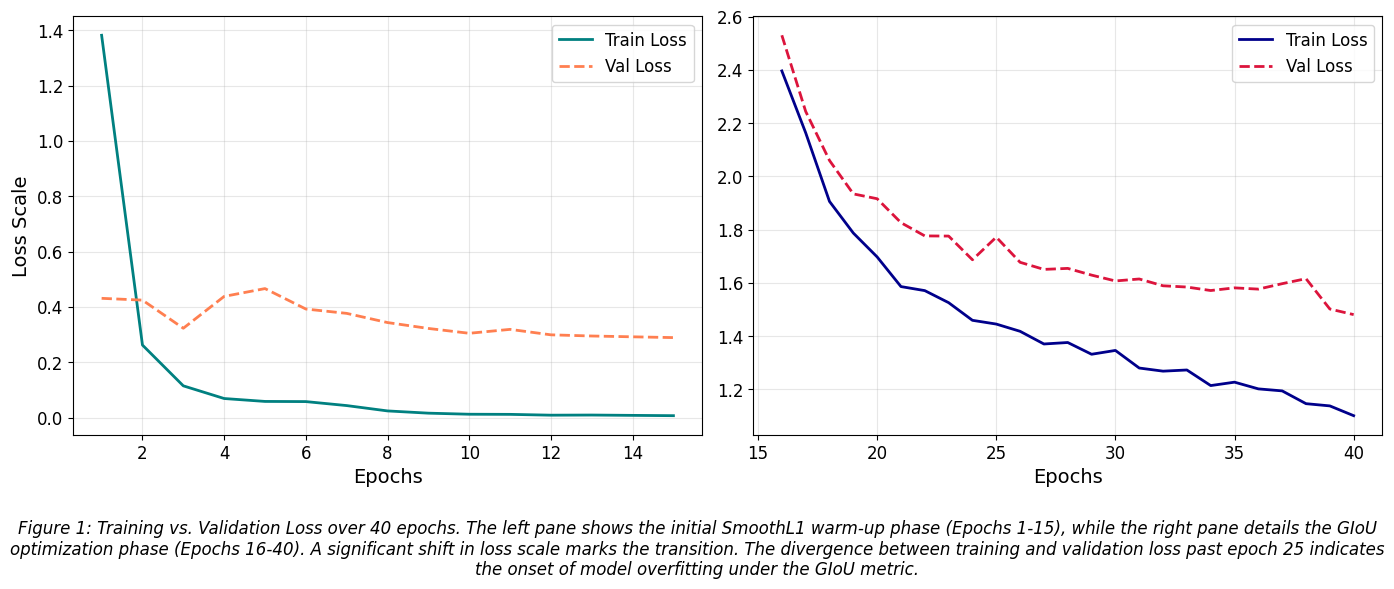

In [ ]:
import matplotlib.pyplot as plt

# Setup side-by-side subplots with slightly extra height to accommodate the caption
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
switch_epoch = 15
epochs = range(1, len(train_losses) + 1)

# --- PLOT 1: Warm-up Phase (Epochs 1 to 15) ---
ax1.plot(epochs[:switch_epoch], train_losses[:switch_epoch], label='Train Loss', color='teal', lw=2)
ax1.plot(epochs[:switch_epoch], val_losses[:switch_epoch], label='Val Loss', color='coral', linestyle='--', lw=2)
ax1.set_xlabel("Epochs", fontsize=14)
ax1.set_ylabel("Loss Scale", fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=12)

# --- PLOT 2: GIoU Convergence Phase (Epochs 16 to 40) ---
ax2.plot(epochs[switch_epoch:], train_losses[switch_epoch:], label='Train Loss', color='darkblue', lw=2)
ax2.plot(epochs[switch_epoch:], val_losses[switch_epoch:], label='Val Loss', color='crimson', linestyle='--', lw=2)
ax2.set_xlabel("Epochs", fontsize=14)
# Left the Y-axis label off ax2 to keep the plot clean, as 'Loss Scale' is implied from ax1
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=12)

# --- ADD FORMAL FIGURE CAPTION ---
caption = (
    "Figure 1: Training vs. Validation Loss over 40 epochs. The left pane shows the initial SmoothL1 warm-up phase (Epochs 1-15), "
    "while the right pane details the GIoU optimization phase (Epochs 16-40). A significant shift in loss scale marks the transition. "
    "The divergence between training and validation loss past epoch 25 indicates the onset of model overfitting under the GIoU metric."
)

# Place text at the bottom center of the figure
plt.figtext(0.5, -0.05, caption, wrap=True, horizontalalignment='center', fontsize=12, style='italic')

# Adjust layout to ensure the caption isn't cut off when saving to an image or PDF
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)

plt.show()

### Evaluating the Model

In [ ]:
def evaluate(model, test_loader, device):
    print("Starting evaluation on test data...")
    # 1. Put model in evaluation mode (freezes BatchNorm and Dropout)
    model.eval()

    # 2. Initialize Metrics
    acc_metric = torchmetrics.Accuracy(task="multiclass", num_classes=37).to(device)
    bbox_metric = MeanAveragePrecision(box_format='xyxy').to(device)

    # 3. Disable gradients to save memory and speed up inference
    with torch.inference_mode():
        for X_tensor_batch, y_label_batch, y_bbox_batch in test_loader:

            # Move data to device
            X_tensor_batch = X_tensor_batch.to(device)
            y_label_batch = y_label_batch.to(device)
            y_bbox_batch = y_bbox_batch.to(device)

            # Squeeze extra dimensions if present
            if y_bbox_batch.dim() == 3 and y_bbox_batch.shape[1] == 1:
                y_bbox_batch = y_bbox_batch.squeeze(1)

            # Forward pass (No loss calculation needed!)
            y_class_preds, y_bbox_preds = model(X_tensor_batch)

            # Enforce geometric correctness for bounding boxes
            x1, y1, x2, y2 = y_bbox_preds.unbind(-1)
            fixed_x1 = torch.min(x1, x2)
            fixed_x2 = torch.max(x1, x2)
            fixed_y1 = torch.min(y1, y2)
            fixed_y2 = torch.max(y1, y2)
            y_bbox_preds_fixed = torch.stack([fixed_x1, fixed_y1, fixed_x2, fixed_y2], dim=-1)

            # --- METRIC UPDATES ---

            # Update Accuracy
            pred_classes = y_class_preds.argmax(dim=-1)
            acc_metric.update(pred_classes, y_label_batch)

            # Update mAP
            probs = torch.softmax(y_class_preds, dim=1)
            scores, pred_labels = torch.max(probs, dim=1)

            # Scale coordinates by 224.0 for torchmetrics area calculation
            preds = [
                {
                    "boxes": (y_bbox_preds_fixed[i] * 224.0).detach().unsqueeze(0),
                    "scores": scores[i].detach().unsqueeze(0),
                    "labels": pred_labels[i].detach().unsqueeze(0),
                }
                for i in range(len(y_bbox_preds_fixed))
            ]

            targets = [
                {
                    "boxes": (y_bbox_batch[i] * 224.0).detach().unsqueeze(0),
                    "labels": y_label_batch[i].detach().unsqueeze(0),
                }
                for i in range(len(y_bbox_batch))
            ]

            bbox_metric.update(preds, targets)

    # --- COMPUTE FINAL SCORES ---
    final_acc = acc_metric.compute().item()

    mAP_results = bbox_metric.compute()
    map_50 = mAP_results['map_50'].item()
    map_75 = mAP_results['map_75'].item()

    print("\n" + "="*30)
    print("      VALIDATION RESULTS      ")
    print("="*30)
    print(f"Classification Acc: {final_acc * 100:.2f}%")
    print(f"Bounding Box mAP@50: {map_50 * 100:.2f}%")
    print(f"Bounding Box mAP@75: {map_75 * 100:.2f}%")
    print("="*30 + "\n")

    return final_acc, map_50, map_75

In [ ]:
evaluate(model, val_loader, device)

Starting evaluation on test data...

      VALIDATION RESULTS      
Classification Acc: 91.29%
Bounding Box mAP@50: 86.64%
Bounding Box mAP@75: 51.58%



(0.9129251837730408, 0.8664369583129883, 0.5158213973045349)

## Writing a unified code to builld both the MobilenetV3 small and efficientnetB0

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import models

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
import torch
import torch.nn as nn
import torchvision

class UnifiedMultiTaskModel(nn.Module):
    def __init__(self, backbone_type="efficientnet", num_classes=37):
        super().__init__()

        backbone_type = backbone_type.lower()

        # 1. Dynamically select the backbone and map its final output channel count
        if backbone_type == "efficientnet":
            base_model = torchvision.models.efficientnet_b0(
                weights=torchvision.models.EfficientNet_B0_Weights.DEFAULT
            )
            self.feature_extractor = base_model.features
            backbone_channels = 1280

        elif backbone_type == "mobilenet":
            base_model = torchvision.models.mobilenet_v3_small(
                weights=torchvision.models.MobileNet_V3_Small_Weights.DEFAULT
            )
            self.feature_extractor = base_model.features
            backbone_channels = 576

        # elif backbone_type == "resnet":
        #     base_model = torchvision.models.resnet34(
        #         weights=torchvision.models.ResNet34_Weights.DEFAULT
        #     )
        #     # Custom sequential to keep the 7x7 grid context for ResNet
        #     self.feature_extractor = nn.Sequential(
        #         base_model.conv1,
        #         base_model.bn1,
        #         base_model.relu,
        #         base_model.maxpool,
        #         base_model.layer1,
        #         base_model.layer2,
        #         base_model.layer3,
        #         base_model.layer4
        #     )
        #     backbone_channels = 512

        else:
            raise ValueError(f"Backbone '{backbone_type}' is not supported. Choose from 'efficientnet', 'mobilenet', or 'resnet'.")

        # 2. Classification Path Layers (Using dynamic channels)
        self.class_pool = nn.AdaptiveAvgPool2d(output_size=1)
        self.class_flatten = nn.Flatten()
        self.classification_head = nn.Linear(in_features=backbone_channels, out_features=num_classes)

        # 3. Localization Path Layers (Using dynamic channels)
        self.loc_conv = nn.Sequential(
            nn.Conv2d(in_channels=backbone_channels, out_channels=64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.loc_flatten = nn.Flatten()
        self.localization_head = nn.Sequential(
            nn.Linear(in_features=64 * 7 * 7, out_features=256),
            nn.BatchNorm1d(num_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=4),
            nn.Sigmoid()
        )

    def forward(self, inputs):
        # Shared features
        spatial_features = self.feature_extractor(inputs)

        # Path A: Classification
        class_features = self.class_flatten(self.class_pool(spatial_features))
        class_logits = self.classification_head(class_features)

        # Path B: Localization
        loc_features = self.loc_conv(spatial_features)
        loc_features = self.loc_flatten(loc_features)
        bbox_coords = self.localization_head(loc_features)

        return class_logits, bbox_coords

### Creating the Efficientnet model and Mobilenet model

In [ ]:
# Create an EfficientNet-B0 version
efficientnet_model = UnifiedMultiTaskModel(backbone_type="efficientnet", num_classes=37).to(device)

# Create a MobileNetV3-Small version
mobilenet_model = UnifiedMultiTaskModel(backbone_type="mobilenet", num_classes=37).to(device)



# Initialize ONLY the custom head layers, leave the backbone intact!
def init_heads(m):
    # Catch both Linear and Conv2d layers
    if isinstance(m, (nn.Linear, nn.Conv2d)):
        nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

    # Catch both 1D and 2D Batch Normalization layers
    elif isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

my_models = [efficientnet_model, mobilenet_model]

# 3. Loop through and initialize only the custom heads
for model in my_models:
    model.classification_head.apply(init_heads)
    model.loc_conv.apply(init_heads) # Initializes the new 2D channel reduction layer
    model.localization_head.apply(init_heads)

print("Successfully initialized all custom head layers while leaving pretrained backbones intact!")

Successfully initialized all custom head layers while leaving pretrained backbones intact!


## Model B- Working with the Efficientnet Model

In [ ]:
import torch

# 1. Define your optimizer as usual
optimizer = torch.optim.AdamW(efficientnet_model.parameters(), lr=1e-4, weight_decay=1e-4)

# 2. Setup ReduceLROnPlateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # We want to MINIMIZE validation loss
    factor=0.2,       # Drop LR to 20% of its value (e.g., 0.001 -> 0.0002)
    patience=3,       # Wait 3 epochs of no improvement before dropping
)

In [ ]:
import torch

def calculate_batch_iou(pred_boxes, target_boxes):
    """Computes IoU scores for a batch of single-object bounding boxes."""
    p_xmin, p_ymin, p_xmax, p_ymax = pred_boxes.unbind(1)
    t_xmin, t_ymin, t_xmax, t_ymax = target_boxes.unbind(1)

    # Calculate intersections
    inter_xmin = torch.max(p_xmin, t_xmin)
    inter_ymin = torch.max(p_ymin, t_ymin)
    inter_xmax = torch.min(p_xmax, t_xmax)
    inter_ymax = torch.min(p_ymax, t_ymax)

    inter_area = torch.clamp(inter_xmax - inter_xmin, min=0) * torch.clamp(inter_ymax - inter_ymin, min=0)

    # Calculate areas
    pred_area = (p_xmax - p_xmin) * (p_ymax - p_ymin)
    target_area = (t_xmax - t_xmin) * (t_ymax - t_ymin)

    union_area = pred_area + target_area - inter_area
    return inter_area / torch.clamp(union_area, min=1e-6)


def train_and_validate(model, optimizer, scheduler, criterion_cls, criterion_smooth_l1, criterion_reg,
                       train_loader, val_loader, n_epochs, switch_epoch=15, device='cuda'):

    history_train_loss = []
    history_val_loss = []
    # NEW: Track classification accuracy histories
    history_train_acc = []
    history_val_acc = []
    # Track mAP histories
    history_map50 = []
    history_map75 = []

    for epoch in range(n_epochs):
        # ================================
        #        TRAINING PHASE
        # ================================
        model.train()
        total_train_loss = 0.
        # NEW: Counters for training accuracy
        correct_train_cls = 0
        total_train_samples = 0

        for X_tensor_batch, y_label_batch, y_bbox_batch in train_loader:
            X_tensor_batch, y_label_batch, y_bbox_batch = X_tensor_batch.to(device), y_label_batch.to(device), y_bbox_batch.to(device)

            if y_bbox_batch.dim() == 3 and y_bbox_batch.shape[1] == 1:
                y_bbox_batch = y_bbox_batch.squeeze(1)

            y_class_preds, y_bbox_preds = model(X_tensor_batch)

            # Enforce geometric correctness safely
            x1, y1, x2, y2 = y_bbox_preds.unbind(-1)
            y_bbox_preds_fixed = torch.stack([torch.min(x1, x2), torch.min(y1, y2),
                                              torch.max(x1, x2), torch.max(y1, y2)], dim=-1)

            loss_cls = criterion_cls(y_class_preds, y_label_batch)

            if epoch < switch_epoch:
                loss_reg = criterion_smooth_l1(y_bbox_preds, y_bbox_batch)
                reg_weight = 3
            else:
                loss_reg = criterion_reg(y_bbox_preds_fixed, y_bbox_batch)
                reg_weight = 5

            loss = loss_cls + reg_weight * loss_reg
            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # --- NEW: TRACK TRAINING ACCURACY ---
            pred_train_classes = torch.argmax(y_class_preds, dim=1)
            correct_train_cls += torch.sum(pred_train_classes == y_label_batch).item()
            total_train_samples += y_label_batch.size(0)

        mean_train_loss = total_train_loss / len(train_loader)
        history_train_loss.append(mean_train_loss)

        # NEW: Calculate training accuracy for the epoch
        epoch_train_acc = correct_train_cls / total_train_samples
        history_train_acc.append(epoch_train_acc)

        # ================================
        #       VALIDATION PHASE
        # ================================
        model.eval()
        total_val_loss = 0.

        # Counters for mAP and accuracy calculations
        correct_val_cls = 0  # NEW: Separate counter for pure classification accuracy
        correct_map50 = 0
        correct_map75 = 0
        total_val_samples = 0

        with torch.inference_mode():
            for X_val, y_label_val, y_bbox_val in val_loader:
                X_val, y_label_val, y_bbox_val = X_val.to(device), y_label_val.to(device), y_bbox_val.to(device)

                if y_bbox_val.dim() == 3 and y_bbox_val.shape[1] == 1:
                    y_bbox_val = y_bbox_val.squeeze(1)

                y_class_preds, y_bbox_preds = model(X_val)

                x1, y1, x2, y2 = y_bbox_preds.unbind(-1)
                y_bbox_preds_fixed = torch.stack([torch.min(x1, x2), torch.min(y1, y2),
                                                  torch.max(x1, x2), torch.max(y1, y2)], dim=-1)

                val_loss_cls = criterion_cls(y_class_preds, y_label_val)

                if epoch < switch_epoch:
                    val_loss_reg = criterion_smooth_l1(y_bbox_preds, y_bbox_val)
                    reg_weight = 3
                else:
                    val_loss_reg = criterion_reg(y_bbox_preds_fixed, y_bbox_val)
                    reg_weight = 5

                val_loss = val_loss_cls + reg_weight * val_loss_reg
                total_val_loss += val_loss.item()

                # --- BATCH METRICS COMPILATION ---
                batch_ious = calculate_batch_iou(y_bbox_preds_fixed, y_bbox_val)
                pred_classes = torch.argmax(y_class_preds, dim=1)

                correct_class = (pred_classes == y_label_val)

                # NEW: Accumulate classification accuracy independently of the bounding box
                correct_val_cls += torch.sum(correct_class).item()

                # mAP constraints (Classification must be correct AND IoU threshold cleared)
                correct_map50 += torch.sum(correct_class & (batch_ious >= 0.50)).item()
                correct_map75 += torch.sum(correct_class & (batch_ious >= 0.75)).item()
                total_val_samples += y_label_val.size(0)

        mean_val_loss = total_val_loss / len(val_loader)
        history_val_loss.append(mean_val_loss)

        # Calculate Epoch Averages
        epoch_val_acc = correct_val_cls / total_val_samples
        epoch_mAP50 = correct_map50 / total_val_samples
        epoch_mAP75 = correct_map75 / total_val_samples

        history_val_acc.append(epoch_val_acc)
        history_map50.append(epoch_mAP50)
        history_map75.append(epoch_mAP75)

        # ================================
        #        UPDATE SCHEDULER
        # ================================
        if epoch == switch_epoch:
            try:
                scheduler._reset()
                print("--> Loss scale transition detected: Resetting scheduler performance tracking.")
            except AttributeError:
                pass

        scheduler.step(mean_val_loss)

        # NEW: Comprehensive Research-Standard Log Output
        print(f"Epoch {epoch + 1:02d}/{n_epochs} | "
              f"Train Loss: {mean_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
              f"Val Loss: {mean_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f} | "
              f"mAP@50: {epoch_mAP50:.4f} | mAP@75: {epoch_mAP75:.4f}")

    # Return all 6 recorded history matrices
    return (history_train_loss, history_val_loss,
            history_train_acc, history_val_acc,
            history_map50, history_map75)

In [ ]:
import time

start_wall_time = time.time()

optimizer = torch.optim.AdamW(
    efficientnet_model.parameters(),  # <-- Crucial change
    lr=0.0001,
    weight_decay=1e-4
)

# RE-INITIALIZE THE SCHEDULER WITH THE NEW OPTIMIZER
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,
    patience=3
)
# Unpack all 6 lists from the updated function
(train_losses, val_losses,
 train_accs, val_accs,
 map50_history, map75_history) = train_and_validate(
    efficientnet_model,
    optimizer,
    scheduler,
    criterion_cls,
    criterion_smooth_l1,
    criterion_reg,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=40
)

end_wall_time = time.time()
total_seconds = end_wall_time - start_wall_time

mins = int(total_seconds // 60)
secs = int(total_seconds % 60)

print(f"\n⏱️ Total Execution Time: {mins}m {secs}s ({total_seconds:.2f} seconds total)")

Epoch 01/40 | Train Loss: 2.9084 | Train Acc: 0.3132 || Val Loss: 1.4827 | Val Acc: 0.6993 | mAP@50: 0.0980 | mAP@75: 0.0027
Epoch 02/40 | Train Loss: 1.1734 | Train Acc: 0.7589 || Val Loss: 0.6579 | Val Acc: 0.8517 | mAP@50: 0.3388 | mAP@75: 0.0354
Epoch 03/40 | Train Loss: 0.6011 | Train Acc: 0.8623 || Val Loss: 0.4556 | Val Acc: 0.8884 | mAP@50: 0.4939 | mAP@75: 0.0803
Epoch 04/40 | Train Loss: 0.3906 | Train Acc: 0.9176 || Val Loss: 0.3912 | Val Acc: 0.8912 | mAP@50: 0.5401 | mAP@75: 0.1265
Epoch 05/40 | Train Loss: 0.2742 | Train Acc: 0.9461 || Val Loss: 0.3352 | Val Acc: 0.9020 | mAP@50: 0.5959 | mAP@75: 0.1020
Epoch 06/40 | Train Loss: 0.2006 | Train Acc: 0.9574 || Val Loss: 0.3111 | Val Acc: 0.9061 | mAP@50: 0.6082 | mAP@75: 0.1429
Epoch 07/40 | Train Loss: 0.1595 | Train Acc: 0.9670 || Val Loss: 0.2873 | Val Acc: 0.9184 | mAP@50: 0.6490 | mAP@75: 0.1741
Epoch 08/40 | Train Loss: 0.1225 | Train Acc: 0.9763 || Val Loss: 0.3073 | Val Acc: 0.9116 | mAP@50: 0.6544 | mAP@75: 0.1714


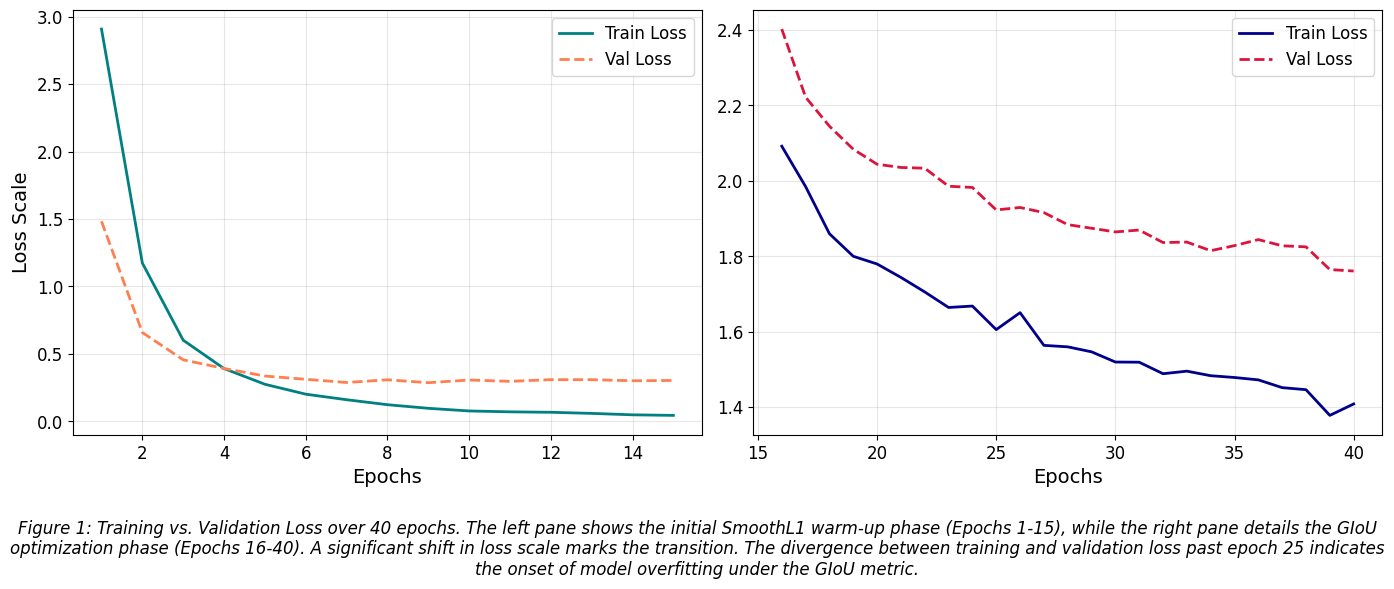

In [ ]:
import matplotlib.pyplot as plt

# Setup side-by-side subplots with slightly extra height to accommodate the caption
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
switch_epoch = 15
epochs = range(1, len(train_losses) + 1)

# --- PLOT 1: Warm-up Phase (Epochs 1 to 15) ---
ax1.plot(epochs[:switch_epoch], train_losses[:switch_epoch], label='Train Loss', color='teal', lw=2)
ax1.plot(epochs[:switch_epoch], val_losses[:switch_epoch], label='Val Loss', color='coral', linestyle='--', lw=2)
ax1.set_xlabel("Epochs", fontsize=14)
ax1.set_ylabel("Loss Scale", fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=12)

# --- PLOT 2: GIoU Convergence Phase (Epochs 16 to 40) ---
ax2.plot(epochs[switch_epoch:], train_losses[switch_epoch:], label='Train Loss', color='darkblue', lw=2)
ax2.plot(epochs[switch_epoch:], val_losses[switch_epoch:], label='Val Loss', color='crimson', linestyle='--', lw=2)
ax2.set_xlabel("Epochs", fontsize=14)
# Left the Y-axis label off ax2 to keep the plot clean, as 'Loss Scale' is implied from ax1
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=12)

# --- ADD FORMAL FIGURE CAPTION ---
caption = (
    "Figure 1: Training vs. Validation Loss over 40 epochs. The left pane shows the initial SmoothL1 warm-up phase (Epochs 1-15), "
    "while the right pane details the GIoU optimization phase (Epochs 16-40). A significant shift in loss scale marks the transition. "
    "The divergence between training and validation loss past epoch 25 indicates the onset of model overfitting under the GIoU metric."
)

# Place text at the bottom center of the figure
plt.figtext(0.5, -0.05, caption, wrap=True, horizontalalignment='center', fontsize=12, style='italic')

# Adjust layout to ensure the caption isn't cut off when saving to an image or PDF
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)

plt.show()

In [ ]:
evaluate(efficientnet_model, val_loader, device)

Starting evaluation on test data...

      VALIDATION RESULTS      
Classification Acc: 90.61%
Bounding Box mAP@50: 79.82%
Bounding Box mAP@75: 26.80%



(0.9061224460601807, 0.7981637716293335, 0.2679923474788666)

## Model C- Working with the The MobileNet

In [ ]:
import torch

# 1. Define your optimizer as usual
optimizer = torch.optim.AdamW(mobilenet_model.parameters(), lr=1e-4, weight_decay=1e-4)

# 2. Setup ReduceLROnPlateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # We want to MINIMIZE validation loss
    factor=0.2,       # Drop LR to 20% of its value (e.g., 0.001 -> 0.0002)
    patience=3,       # Wait 3 epochs of no improvement before dropping
)

In [ ]:
import time

start_wall_time = time.time()

optimizer = torch.optim.AdamW(
    mobilenet_model.parameters(),  # <-- Crucial change
    lr=0.0001,
    weight_decay=1e-4
)

# RE-INITIALIZE THE SCHEDULER WITH THE NEW OPTIMIZER
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,
    patience=3
)
# Unpack all 6 lists from the updated function
(train_losses, val_losses,
 train_accs, val_accs,
 map50_history, map75_history) = train_and_validate(
    mobilenet_model,
    optimizer,
    scheduler,
    criterion_cls,
    criterion_smooth_l1,
    criterion_reg,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=40
)

end_wall_time = time.time()
total_seconds = end_wall_time - start_wall_time

mins = int(total_seconds // 60)
secs = int(total_seconds % 60)

print(f"\n⏱️ Total Execution Time: {mins}m {secs}s ({total_seconds:.2f} seconds total)")

Epoch 01/40 | Train Loss: 3.6944 | Train Acc: 0.0776 || Val Loss: 3.2224 | Val Acc: 0.1741 | mAP@50: 0.0177 | mAP@75: 0.0000
Epoch 02/40 | Train Loss: 2.8862 | Train Acc: 0.2826 || Val Loss: 2.5252 | Val Acc: 0.3728 | mAP@50: 0.1007 | mAP@75: 0.0068
Epoch 03/40 | Train Loss: 2.2164 | Train Acc: 0.4997 || Val Loss: 1.9665 | Val Acc: 0.4980 | mAP@50: 0.1946 | mAP@75: 0.0150
Epoch 04/40 | Train Loss: 1.6921 | Train Acc: 0.6377 || Val Loss: 1.5751 | Val Acc: 0.6068 | mAP@50: 0.2857 | mAP@75: 0.0395
Epoch 05/40 | Train Loss: 1.3472 | Train Acc: 0.7026 || Val Loss: 1.3480 | Val Acc: 0.6490 | mAP@50: 0.3320 | mAP@75: 0.0503
Epoch 06/40 | Train Loss: 1.1048 | Train Acc: 0.7534 || Val Loss: 1.1742 | Val Acc: 0.6898 | mAP@50: 0.3755 | mAP@75: 0.0694
Epoch 07/40 | Train Loss: 0.9189 | Train Acc: 0.7936 || Val Loss: 1.0649 | Val Acc: 0.7156 | mAP@50: 0.3986 | mAP@75: 0.0680
Epoch 08/40 | Train Loss: 0.7737 | Train Acc: 0.8328 || Val Loss: 0.9734 | Val Acc: 0.7320 | mAP@50: 0.4272 | mAP@75: 0.0925


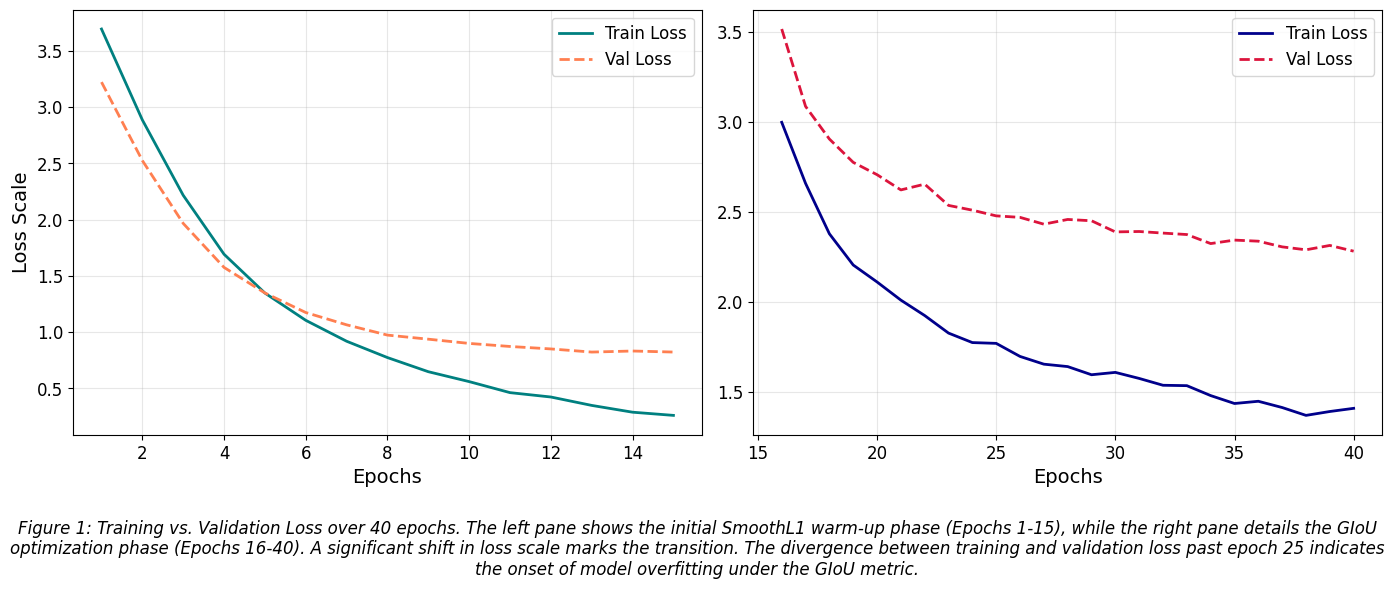

In [ ]:
import matplotlib.pyplot as plt

# Setup side-by-side subplots with slightly extra height to accommodate the caption
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
switch_epoch = 15
epochs = range(1, len(train_losses) + 1)

# --- PLOT 1: Warm-up Phase (Epochs 1 to 15) ---
ax1.plot(epochs[:switch_epoch], train_losses[:switch_epoch], label='Train Loss', color='teal', lw=2)
ax1.plot(epochs[:switch_epoch], val_losses[:switch_epoch], label='Val Loss', color='coral', linestyle='--', lw=2)
ax1.set_xlabel("Epochs", fontsize=14)
ax1.set_ylabel("Loss Scale", fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=12)

# --- PLOT 2: GIoU Convergence Phase (Epochs 16 to 40) ---
ax2.plot(epochs[switch_epoch:], train_losses[switch_epoch:], label='Train Loss', color='darkblue', lw=2)
ax2.plot(epochs[switch_epoch:], val_losses[switch_epoch:], label='Val Loss', color='crimson', linestyle='--', lw=2)
ax2.set_xlabel("Epochs", fontsize=14)
# Left the Y-axis label off ax2 to keep the plot clean, as 'Loss Scale' is implied from ax1
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=12)

# --- ADD FORMAL FIGURE CAPTION ---
caption = (
    "Figure 1: Training vs. Validation Loss over 40 epochs. The left pane shows the initial SmoothL1 warm-up phase (Epochs 1-15), "
    "while the right pane details the GIoU optimization phase (Epochs 16-40). A significant shift in loss scale marks the transition. "
    "The divergence between training and validation loss past epoch 25 indicates the onset of model overfitting under the GIoU metric."
)

# Place text at the bottom center of the figure
plt.figtext(0.5, -0.05, caption, wrap=True, horizontalalignment='center', fontsize=12, style='italic')

# Adjust layout to ensure the caption isn't cut off when saving to an image or PDF
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)

plt.show()

In [ ]:
evaluate(mobilenet_model, val_loader, device)

Starting evaluation on test data...

      VALIDATION RESULTS      
Classification Acc: 77.69%
Bounding Box mAP@50: 68.20%
Bounding Box mAP@75: 27.05%



(0.7768707275390625, 0.6819723844528198, 0.27049803733825684)